In [1]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
data_generator = ImageDataGenerator(
    rescale=1.0/255.0,
    zoom_range=0.4,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=50,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.4,
    fill_mode='nearest'
)
train = data_generator.flow_from_directory('./data/PetImagesTrain', class_mode='binary', batch_size=50, target_size=(200, 200))

Found 16139 images belonging to 2 classes.


In [ ]:
test = data_generator.flow_from_directory('./data/PetImagesTest', class_mode='binary', batch_size=50, target_size=(200, 200))

Found 1666 images belonging to 2 classes.


In [4]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(200,200,3)),
    MaxPool2D(2,2),
    Dropout(0.2),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPool2D(2,2),
    Dropout(0.2),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPool2D(2,2),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

c:\Users\Erfan Hosseini\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,240,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,333,505 (39.42 MB)

 Trainable params: 10,333,505 (39.42 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer=Adam(), loss=BinaryCrossentropy(), metrics=[BinaryAccuracy()])

In [7]:
history = model.fit(train, steps_per_epoch=len(train), validation_data=test, validation_steps=len(test), epochs=50)

Epoch 1/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 240s 736ms/step - binary_accuracy: 0.5259 - loss: 0.7257 - val_binary_accuracy: 0.5504 - val_loss: 0.6813
Epoch 2/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 227s 703ms/step - binary_accuracy: 0.5391 - loss: 0.6894 - val_binary_accuracy: 0.5960 - val_loss: 0.6775
Epoch 3/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 226s 700ms/step - binary_accuracy: 0.5700 - loss: 0.6753 - val_binary_accuracy: 0.5546 - val_loss: 0.6578
Epoch 4/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 229s 710ms/step - binary_accuracy: 0.6044 - loss: 0.6541 - val_binary_accuracy: 0.6327 - val_loss: 0.6315
Epoch 5/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 227s 701ms/step - binary_accuracy: 0.6282 - loss: 0.6371 - val_binary_accuracy: 0.6429 - val_loss: 0.6283
Epoch 6/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 227s 702ms/step - binary_accuracy: 0.6432 - loss: 0.6252 - val_binary_accuracy: 0.6717 - val_loss: 0.5974
Epoch 7/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 229s 709ms/step - binary_accuracy: 0.6598 - loss: 0.6130 - val_binary_accuracy: 0.68

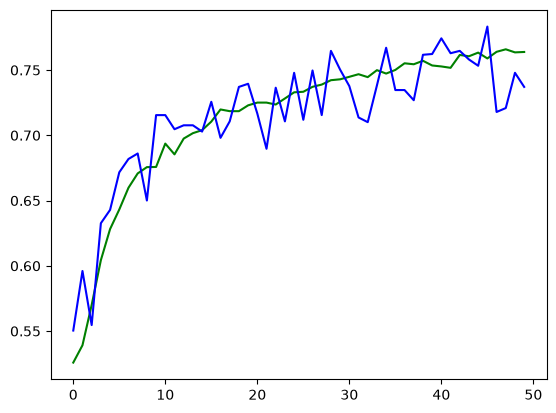

In [12]:
import matplotlib.pyplot as plt
plt.plot(history.history['binary_accuracy'], color='green')
plt.plot(history.history['val_binary_accuracy'], color='blue')

In [13]:
model.save('catvsdog.h5')